# Study 04 — What happens when frame probabilities are no longer independent?

## Question

Study 03 assumed that a player's probability of winning each frame was fixed and that every frame was independent of the frames before it.

That gave us a simple model. If Trump had a 58% chance of winning every frame, his probability of winning a best-of-N match could be calculated exactly using the binomial distribution.

Real sport may not behave like that.

Players can appear to gain or lose momentum during a match. Winning one frame might make a player more likely to win the next, while losing one might reduce that probability.

This study introduces **one complication only**:

> **The probability of winning the next frame will depend on who won the previous frame.**

Everything else will remain unchanged.

We are not yet claiming that momentum really exists in snooker, or trying to estimate its true size. We are asking a simpler modelling question:

**If frame outcomes really do affect the probability of the next frame, what happens to match outcomes?**

Because the frames are now dependent on one another, the simple binomial calculation from Study 03 no longer applies cleanly.

That gives Monte Carlo simulation a genuinely new job: following the changing state of the match frame by frame.

## A simple momentum rule

We will keep Trump's overall frame-win probability at **58%**, as in Study 03.

The only change is that the winner of the previous frame affects Trump's probability of winning the next one:

- first frame: **58%**
- if Trump won the previous frame: **63%**
- if Murphy won the previous frame: approximately **51.1%**

The two momentum probabilities are deliberately not symmetric around 58%.

Because Trump is already more likely than Murphy to win a frame, a simple `+5 / -5` rule would make Trump spend more time in the favourable state and would therefore increase his overall frame-win probability.

The 51.1% value is calibrated so that the model retains Trump's 58% baseline strength while introducing dependence between consecutive frames.

We are therefore changing **one thing only**: whether frame outcomes are independent.

In [5]:
import numpy as np

# Keep Trump's long-run frame strength at 58% while allowing the
# previous frame winner to affect the next-frame probability.
p_baseline = 0.58
p_after_trump_win = 0.63
p_after_murphy_win = 0.51095

# Best of 7 means first to 4 frames.
frames_to_win = 4

# Reproducible random-number generator.
rng = np.random.default_rng(42)

# Start at 0–0 with no previous-frame state, so frame 1 uses 58%.
trump_frames = 0
murphy_frames = 0
previous_winner = None
frame_history = []

while trump_frames < frames_to_win and murphy_frames < frames_to_win:

    # Set Trump's next-frame probability from the current match state.
    if previous_winner is None:
        p_trump = p_baseline
    elif previous_winner == "Trump":
        p_trump = p_after_trump_win
    else:
        p_trump = p_after_murphy_win

    # Simulate the frame using that state-dependent probability.
    if rng.random() < p_trump:
        winner = "Trump"
        trump_frames += 1
    else:
        winner = "Murphy"
        murphy_frames += 1

    # Keep the probability, winner and resulting score so we can see
    # how one frame changes the conditions for the next.
    frame_history.append(
        (p_trump, winner, trump_frames, murphy_frames)
    )

    previous_winner = winner

frame_history

[(0.58, 'Murphy', 0, 1),
 (0.51095, 'Trump', 1, 1),
 (0.63, 'Murphy', 1, 2),
 (0.51095, 'Murphy', 1, 3),
 (0.51095, 'Trump', 2, 3),
 (0.63, 'Murphy', 2, 4)]

### What changed?

In Study 03, every frame was a fresh 58% versus 42% contest.

Here, the probability of the next frame depends on what happened immediately before it.

For example, after Murphy won the first frame, Trump's probability of winning frame 2 fell from 58% to about 51.1%. When Trump then won frame 2, his probability for frame 3 rose to 63%.

This means the frame outcomes are no longer independent.

A sequence of previous results can affect the probabilities of later results, so we can no longer treat the match simply as repeated trials with one fixed probability.

In [6]:
def simulate_momentum_match(
    rng,
    frames_to_win,
    p_baseline=0.58,
    p_after_trump_win=0.63,
    p_after_murphy_win=0.51095,
):
    # Start every simulated match at 0–0 with no previous-frame state.
    # The first frame therefore uses the baseline 58% Trump probability.
    trump_frames = 0
    murphy_frames = 0
    previous_winner = None

    # Continue until either player reaches the number of frames needed
    # to win the match.
    while trump_frames < frames_to_win and murphy_frames < frames_to_win:

        # Unlike Study 03, Trump's frame-win probability is not fixed.
        # It depends on who won the immediately preceding frame.
        if previous_winner is None:
            p_trump = p_baseline
        elif previous_winner == "Trump":
            p_trump = p_after_trump_win
        else:
            p_trump = p_after_murphy_win

        # Draw the next frame using the probability implied by the
        # current match state.
        if rng.random() < p_trump:
            trump_frames += 1

            # This result changes the probability used for the next frame.
            previous_winner = "Trump"
        else:
            murphy_frames += 1

            # A Murphy win likewise changes the next-frame state.
            previous_winner = "Murphy"

    # A single simulation only needs to tell us whether Trump won.
    # Repeating this many times estimates his match-win probability.
    return trump_frames == frames_to_win

In [7]:
# Run one dependent best-of-7 match.
simulate_momentum_match(rng, frames_to_win=4)

False

In [8]:
# Use a fresh generator so this experiment is reproducible independently
# of the earlier single-match examples.
rng = np.random.default_rng(42)

# A large number of simulated matches reduces Monte Carlo noise enough
# for a clear comparison with the fixed-probability model later.
n_simulations = 100_000

# Each result is True when Trump wins the simulated best-of-7 match
# and False when Murphy wins.
momentum_results = [
    simulate_momentum_match(rng, frames_to_win=4)
    for _ in range(n_simulations)
]

# The mean of Boolean values is the proportion of matches Trump won,
# which estimates his match-win probability under this dependent model.
momentum_win_probability = np.mean(momentum_results)

momentum_win_probability

np.float64(0.65816)

### First result

Across 100,000 simulated best-of-7 matches, Trump won about **65.8%** under the momentum model.

In Study 03, with independent frames and a fixed 58% frame-win probability, Trump's exact best-of-7 match-win probability was about **67.1%**.

That is already an important difference.

We have not made Trump a weaker frame player in the long run. Instead, we have changed the way his wins and losses are distributed through time.

Under independence, each frame gives Trump a fresh 58% chance and repeated frames tend to allow his underlying advantage to accumulate.

Under the momentum model, results are more likely to cluster. A Murphy win makes another Murphy win more likely, just as a Trump win makes another Trump win more likely.

That extra streakiness gives the weaker player more opportunity to assemble the short run of frame wins needed to win the match.

So two players can have the same long-run frame strengths but different match-win probabilities depending on whether frame outcomes are independent.

### Why did Trump's match-win probability fall?

Under the independent model from Study 03, Trump has a 58% chance of winning every frame regardless of what happened before it.

For a best-of-7 match, that gives him an exact match-win probability of about **67.1%**.

Under our dependent model, Trump still has the same **58% long-run frame strength**, but his best-of-7 match-win probability falls to about **65.8%**.

The difference comes from **clustering**.

If Trump wins a frame, his chance of winning the next rises to 63%. That makes another Trump win more likely.

But the same mechanism works for Murphy. If Murphy wins a frame, Trump's chance of winning the next falls to about 51.1%, so Murphy's chance rises to about 48.9%.

That makes runs such as:

`Trump → Trump → Trump`

and

`Murphy → Murphy → Murphy`

more likely than they would be if every frame were independent.

This matters because a match is not decided by a player's average performance over an unlimited number of frames. A best-of-7 ends as soon as somebody reaches four wins.

The weaker player therefore does not need to be better in the long run. Murphy only needs a sufficiently favourable **short sequence** before Trump reaches four frames.

Dependence makes those short sequences more likely.

So the important distinction is:

> **The same average frame-win probability does not necessarily imply the same match-win probability.**

The ordering of results matters once consecutive frames are dependent.

This is something the simple binomial model from Study 03 cannot represent. The binomial calculation assumes that every frame is an independent trial with the same probability.

Our Monte Carlo simulation can instead carry the result of one frame forward and use it to change the probability of the next.

In [9]:
# Compare several match lengths while keeping the momentum rule unchanged.
# Only the number of frames needed to win the match will vary.
match_formats = {
    7: 4,
    11: 6,
    19: 10,
    35: 18,
}

# Use a fresh generator so this experiment is reproducible on its own.
rng = np.random.default_rng(42)

n_simulations = 100_000
momentum_by_length = []

for best_of, frames_to_win in match_formats.items():

    # Simulate the same dependent frame process for each match format.
    # The 58% long-run strength and momentum probabilities do not change.
    trump_wins = sum(
        simulate_momentum_match(rng, frames_to_win=frames_to_win)
        for _ in range(n_simulations)
    )

    # Estimate Trump's chance of winning this match format.
    match_win_probability = trump_wins / n_simulations

    momentum_by_length.append(
        (best_of, match_win_probability)
    )

momentum_by_length

[(7, 0.65816), (11, 0.68699), (19, 0.73884), (35, 0.80197)]

In [10]:
from math import comb

# Calculate the independent-frame baseline directly rather than
# copying results from Study 03 as unexplained constants.
def exact_independent_match_probability(best_of, p_trump=0.58):
    frames_to_win = best_of // 2 + 1

    # Trump wins the match if he wins at least the required number
    # of frames out of the maximum possible frames.
    return sum(
        comb(best_of, trump_wins)
        * p_trump**trump_wins
        * (1 - p_trump)**(best_of - trump_wins)
        for trump_wins in range(frames_to_win, best_of + 1)
    )


comparison = []

for best_of, momentum_probability in momentum_by_length:

    # This is the exact Study 03-style result: fixed 58% probability
    # and independent frames.
    independent_probability = exact_independent_match_probability(best_of)

    # The difference isolates what changes when frame dependence is added.
    difference = momentum_probability - independent_probability

    comparison.append(
        (
            best_of,
            independent_probability,
            momentum_probability,
            difference,
        )
    )

comparison

[(7, 0.6705883933695999, 0.65816, -0.012428393369599888),
 (11, 0.7076012138061588, 0.68699, -0.020611213806158823),
 (19, 0.7615393357559487, 0.73884, -0.022699335755948624),
 (35, 0.8313615084019516, 0.80197, -0.029391508401951594)]

### Dependence weakens the stronger player's benefit from longer matches

The independent and dependent models agree on the broad direction: **longer matches still favour Trump**, because he remains the stronger frame player.

But they disagree about how quickly that advantage grows.

| Match length | Independent frames | Dependent frames | Difference |
|---|---:|---:|---:|
| Best of 7 | 67.1% | 65.8% | -1.2 pp |
| Best of 11 | 70.8% | 68.7% | -2.1 pp |
| Best of 19 | 76.2% | 73.9% | -2.3 pp |
| Best of 35 | 83.1% | 80.2% | -2.9 pp |

The important point is not that momentum reverses the effect of match length. It does not.

Trump's match-win probability still rises from about 65.8% in a best-of-7 to about 80.2% in a best-of-35.

Instead, dependence **dampens** the advantage that longer matches give the stronger player.

Under independent frames, every new frame is another fresh opportunity for Trump's 58% edge to assert itself.

Under the dependent model, wins and losses are more likely to arrive in runs. That gives Murphy more opportunity to put together the temporary sequence of frame wins needed to reach the winning target before Trump's underlying advantage fully asserts itself.

In these simulations, the gap between the two models is about 1.2 percentage points in a best-of-7 and about 2.9 percentage points in a best-of-35.

So match length still matters — but **how frame outcomes are related to one another matters too**.

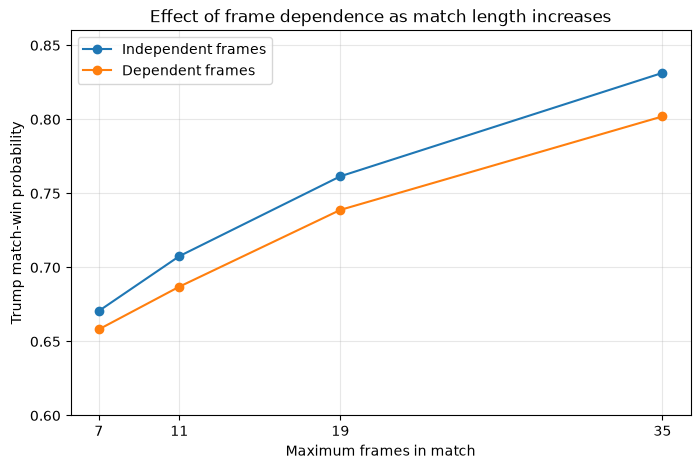

In [12]:
import matplotlib.pyplot as plt

# Separate the comparison results into values that are easy to plot.
best_of_values = [row[0] for row in comparison]
independent_probabilities = [row[1] for row in comparison]
momentum_probabilities = [row[2] for row in comparison]

# Plot both models on the same axes so we can compare how match length
# changes Trump's win probability under independence and dependence.
plt.figure(figsize=(8, 5))

plt.plot(
    best_of_values,
    independent_probabilities,
    marker="o",
    label="Independent frames",
)

plt.plot(
    best_of_values,
    momentum_probabilities,
    marker="o",
    label="Dependent frames",
)

# Use percentage-style values on the vertical axis for easier reading.
plt.xlabel("Maximum frames in match")
plt.ylabel("Trump match-win probability")
plt.title("Effect of frame dependence as match length increases")
plt.xticks(best_of_values)
plt.ylim(0.60, 0.86)
plt.grid(alpha=0.3)
plt.legend()

plt.show()

### What the graph shows

Both models still produce the main result from Study 03: **longer matches favour the stronger player**.

Trump's match-win probability rises steadily as the maximum match length increases, whether frames are independent or dependent.

But the two models do not rise at the same rate.

The dependent-frame line remains below the independent-frame line at every match length we tested. The difference grows from about **1.2 percentage points** in a best-of-7 to about **2.9 percentage points** in a best-of-35.

So introducing dependence does not overturn the advantage of a longer match. Instead, it reduces how strongly that advantage accumulates.

The reason is that dependence changes the pattern of results. Wins and losses are more likely to cluster, giving the weaker player a greater chance of producing the temporary run needed to reach the winning target first.

The graph therefore illustrates the central result of this study:

> **Match length matters, but the structure of the frame-to-frame process matters too.**

Two models can give Trump the same 58% long-run frame strength and still produce different match-win probabilities.

In [13]:
# Check that the dependent process still preserves Trump's intended
# 58% long-run frame strength rather than quietly changing player ability.
rng = np.random.default_rng(42)

n_frames = 1_000_000
trump_wins = 0
previous_winner = None

for _ in range(n_frames):

    # The next-frame probability depends only on the previous winner,
    # using the same rule as the match simulation.
    if previous_winner is None:
        p_trump = p_baseline
    elif previous_winner == "Trump":
        p_trump = p_after_trump_win
    else:
        p_trump = p_after_murphy_win

    # Simulate the frame and carry its result into the next one.
    if rng.random() < p_trump:
        trump_wins += 1
        previous_winner = "Trump"
    else:
        previous_winner = "Murphy"

# Over a very long sequence, Trump's observed frame-win rate should
# settle close to the intended 58% baseline.
observed_frame_win_rate = trump_wins / n_frames

observed_frame_win_rate

0.580094

### Sanity check — did we really preserve Trump's 58% frame strength?

Yes.

Across 1,000,000 consecutive dependent frames, Trump won **58.0094%** of them.

That is extremely close to the intended 58% long-run frame-win rate.

The small difference is ordinary Monte Carlo sampling noise.

This check matters because a simple symmetric momentum rule could change two things at once: it could introduce dependence while also changing Trump's average frame strength.

The calibrated rule avoids that problem.

We can therefore interpret the difference between the independent and dependent match results as coming from **the structure of the frame sequence**, rather than from Trump simply becoming a stronger or weaker player.

So the comparison is now clean:

- same long-run Trump frame strength: about **58%**;
- same match formats;
- one changed assumption: **whether consecutive frames are independent**.

In [14]:
# Test whether dependence actually makes consecutive results more likely
# to repeat than they are under independent 58% frames.
rng = np.random.default_rng(42)

n_frames = 1_000_000

# ----- Independent model -----

independent_winners = rng.random(n_frames) < 0.58

# Compare every frame with the frame immediately before it.
# True means the same player won both consecutive frames.
independent_repeats = (
    independent_winners[1:] == independent_winners[:-1]
)

independent_repeat_rate = np.mean(independent_repeats)


# ----- Dependent model -----

dependent_winners = []
previous_winner = None

for _ in range(n_frames):

    # Apply the same calibrated momentum rule used in the match model.
    if previous_winner is None:
        p_trump = p_baseline
    elif previous_winner:
        p_trump = p_after_trump_win
    else:
        p_trump = p_after_murphy_win

    trump_wins_frame = rng.random() < p_trump
    dependent_winners.append(trump_wins_frame)

    # Carry this result forward as the state for the next frame.
    previous_winner = trump_wins_frame

dependent_winners = np.array(dependent_winners)

dependent_repeats = (
    dependent_winners[1:] == dependent_winners[:-1]
)

dependent_repeat_rate = np.mean(dependent_repeats)

independent_repeat_rate, dependent_repeat_rate

(np.float64(0.5133155133155133), np.float64(0.5717445717445717))

### Dependence really does create more clustering

The explanation for the different match probabilities was that dependence makes results more likely to arrive in runs.

We can test that directly.

Across 1,000,000 simulated frames:

- independent model: the same player won consecutive frames about **51.3%** of the time;
- dependent model: the same player won consecutive frames about **57.2%** of the time.

The independent result is what we would expect from a 58% versus 42% contest. Without any dependence, the probability that the same player wins two consecutive frames is:

$$
(0.58)^2 + (0.42)^2 \approx 0.5128
$$

or about **51.3%**.

The simulation closely reproduces that value.

Under the dependent model, however, the previous winner receives an advantage in the next frame. Consecutive wins therefore occur substantially more often.

This gives direct evidence for the mechanism behind the earlier match results:

> **The dependent model has not changed Trump's long-run strength. It has changed how wins and losses are arranged.**

Frames are more likely to cluster into runs, and those runs give the weaker player more opportunity to reach the match-winning target during a favourable spell.

In [15]:
# Turn a sequence of frame winners into lengths of consecutive winning runs.
# Example: T, T, M, M, M, T becomes run lengths 2, 3, 1.
def get_run_lengths(winners):
    run_lengths = []
    current_run = 1

    for i in range(1, len(winners)):
        if winners[i] == winners[i - 1]:
            current_run += 1
        else:
            run_lengths.append(current_run)
            current_run = 1

    # Record the final run after the loop ends.
    run_lengths.append(current_run)

    return np.array(run_lengths)


# Measure winning runs in the same million-frame sequences used above.
independent_run_lengths = get_run_lengths(independent_winners)
dependent_run_lengths = get_run_lengths(dependent_winners)

# Compare the typical run length and the frequency of clearly visible streaks.
run_comparison = {
    "independent_mean_run": np.mean(independent_run_lengths),
    "dependent_mean_run": np.mean(dependent_run_lengths),
    "independent_runs_3_plus": np.mean(independent_run_lengths >= 3),
    "dependent_runs_3_plus": np.mean(dependent_run_lengths >= 3),
}

run_comparison

{'independent_mean_run': np.float64(2.0547171168209415),
 'dependent_mean_run': np.float64(2.3350519315549576),
 'independent_runs_3_plus': np.float64(0.2574046868097435),
 'dependent_runs_3_plus': np.float64(0.31919692893969964)}

### The dependent model produces longer winning runs

The increased clustering also appears in the lengths of consecutive winning runs.

Across the same 1,000,000-frame simulations:

| Measure | Independent frames | Dependent frames |
|---|---:|---:|
| Mean winning-run length | 2.05 frames | 2.34 frames |
| Runs lasting 3+ frames | 25.7% | 31.9% |

Under the independent model, a run by either player lasts about **2.05 frames on average**.

Under the dependent model, that rises to about **2.34 frames**.

The difference is also visible in longer streaks. About **25.7%** of winning runs last at least three frames under independence, compared with **31.9%** when the previous frame affects the next one.

So the dependent model is behaving as intended.

It has not altered Trump's long-run 58% frame strength. Instead, it has redistributed the same overall balance of wins and losses into **longer clusters**.

That helps explain the match-level result.

A player does not need to dominate forever to win a finite match. They only need to reach the required number of frames first. By making favourable spells more persistent, dependence gives Murphy more opportunity to assemble the short run of wins needed for an upset.

The stronger player still benefits from a longer match, but the benefit is smaller than it would be if every frame were an independent fresh start.

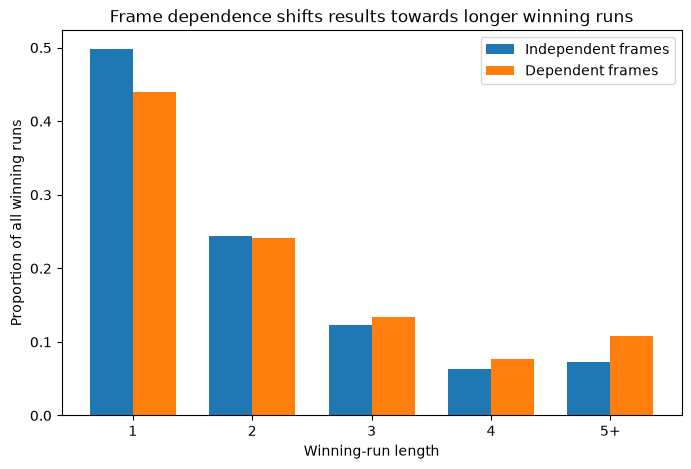

In [16]:
# Compare the distribution of winning-run lengths under the two models.
# We group all runs of five frames or more together so the graph stays readable.
run_categories = ["1", "2", "3", "4", "5+"]

def run_length_distribution(run_lengths):
    total_runs = len(run_lengths)

    return [
        np.mean(run_lengths == 1),
        np.mean(run_lengths == 2),
        np.mean(run_lengths == 3),
        np.mean(run_lengths == 4),
        np.mean(run_lengths >= 5),
    ]


independent_distribution = run_length_distribution(independent_run_lengths)
dependent_distribution = run_length_distribution(dependent_run_lengths)

# Put the two distributions side by side for each run length.
x = np.arange(len(run_categories))
width = 0.36

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    independent_distribution,
    width,
    label="Independent frames",
)

plt.bar(
    x + width / 2,
    dependent_distribution,
    width,
    label="Dependent frames",
)

plt.xlabel("Winning-run length")
plt.ylabel("Proportion of all winning runs")
plt.title("Frame dependence shifts results towards longer winning runs")
plt.xticks(x, run_categories)
plt.legend()

plt.show()

### Where does the extra clustering appear?

The distribution makes the effect of dependence more visible.

Under the dependent model, isolated one-frame wins become less common, while longer runs become more common.

The biggest change is not simply that every run gets slightly longer. Instead, probability is shifted away from very short sequences and towards sustained spells:

- one-frame runs become substantially less common;
- two-frame runs change relatively little;
- runs of three or four frames become more common;
- runs of five or more frames become noticeably more common.

This is exactly the kind of change that can matter in a finite match.

A best-of-7 requires only four frame wins. A sufficiently long favourable run can therefore decide the match before the stronger player's long-run advantage has much opportunity to reassert itself.

The graph helps make the distinction clear:

> **Dependence changes not just how many frames each player wins, but how those wins are arranged.**

That arrangement can affect who reaches the match-winning total first.